# Plant Health Classification: SVM
**Member:** Perera M.A.S.A  
**Student ID:** IT25103606  
**Assigned preprocessing contribution:** Standardization  
**Individual model:** SVM

Predict Healthy, Moderate Stress or High Stress from 11 sensor measurements. The assigned CSV has 1,200 observations from 10 plants and 14 columns including Timestamp, Plant_ID and the target. The original collection and label-assignment methods are unverified. We evaluate on plants excluded from training; this is not a future-time forecasting evaluation.

All members use the same raw data, random seed 42, eight training plants and two test plants. All preprocessing demonstrations are followed by a fresh pipeline fit within each CV training fold. The test set was previously inspected in the group's initial two-model stage; retain this disclosed development history and do not tune to test results.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit


RANDOM_STATE = 42

In [2]:
from pathlib import Path
filename = Path("plant_health_data.csv")
if not filename.exists():
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError("Place plant_health_data.csv beside this notebook.")
    uploaded = files.upload()
    candidates = [name for name in uploaded if name.lower().endswith(".csv")]
    if len(candidates) != 1:
        raise ValueError("Upload exactly one CSV: the supplied plant_health_data.csv.")
    filename = Path(candidates[0])
df = pd.read_csv(filename)
assert df.shape == (1200, 14), "Check that you loaded the assigned dataset."
display(df.head())
print("Dataset shape:", df.shape)


Saving plant_health_data.csv to plant_health_data.csv


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


Dataset shape: (1200, 14)


In [3]:
df.info()

print("\nMissing values:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

print("\nHealth-class counts:")
print(df["Plant_Health_Status"].value_counts())

print("\nNumber of plants:", df["Plant_ID"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), int64(1), object(2)
memo

In [4]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        df,
        y=df["Plant_Health_Status"],
        groups=df["Plant_ID"]
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

train_plants = set(train_df["Plant_ID"])
test_plants = set(test_df["Plant_ID"])

assert train_plants.isdisjoint(test_plants)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training plants:", sorted(train_plants))
print("Testing plants:", sorted(test_plants))

print("\nClass counts in each set:")
display(
    pd.DataFrame({
        "Training": train_df["Plant_Health_Status"].value_counts(),
        "Testing": test_df["Plant_Health_Status"].value_counts()
    }).fillna(0).astype(int)
)

Training rows: 960
Testing rows: 240
Training plants: [1, 3, 4, 5, 6, 7, 8, 10]
Testing plants: [2, 9]

Class counts in each set:


,Training,Testing
Plant_Health_Status,,
High Stress,390,110
Moderate Stress,335,66
Healthy,235,64


**Preprocessing Part 1: Target Label Encoding**

We convert the three text labels into numerical class identifiers: Healthy = 0, Moderate Stress = 1, and High Stress = 2. These numbers identify categories; the classifiers are not being asked to predict a continuous stress score. Decision Tree and SVM can also accept string labels, but this mapping gives our project a consistent numerical target representation.

In [5]:
target_map = {
    "Healthy": 0,
    "Moderate Stress": 1,
    "High Stress": 2
}

class_names = list(target_map.keys())

y_train = train_df["Plant_Health_Status"].map(target_map)
y_test = test_df["Plant_Health_Status"].map(target_map)

assert y_train.notna().all(), "Unexpected training label found."
assert y_test.notna().all(), "Unexpected testing label found."

y_train = y_train.astype(int)
y_test = y_test.astype(int)

encoding_preview = pd.DataFrame({
    "Original label": train_df["Plant_Health_Status"],
    "Encoded label": y_train
})

display(encoding_preview.head(10))
print("Label mapping:", target_map)

,Original label,Encoded label
0,High Stress,2
1,High Stress,2
2,High Stress,2
3,High Stress,2
4,High Stress,2
5,High Stress,2
6,High Stress,2
7,Moderate Stress,1
8,High Stress,2
9,High Stress,2


Label mapping: {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}


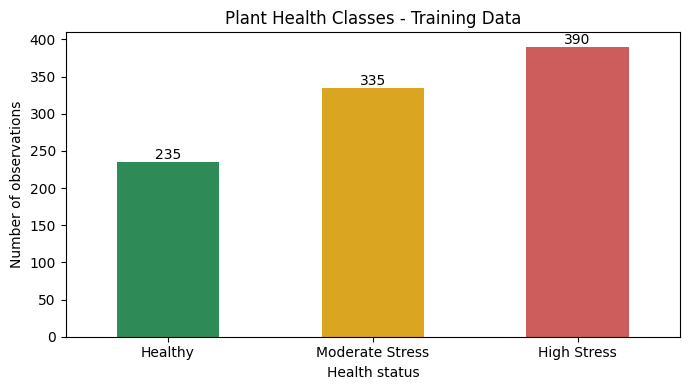

In [6]:
counts = (
    train_df["Plant_Health_Status"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

ax = counts.plot(
    kind="bar",
    color=["seagreen", "goldenrod", "indianred"],
    figsize=(7, 4)
)

ax.set_title("Plant Health Classes - Training Data")
ax.set_xlabel("Health status")
ax.set_ylabel("Number of observations")
ax.bar_label(ax.containers[0])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The training dataset contains 960 observations: 235 Healthy, 335 Moderate Stress, and 390 High Stress. High Stress is the largest class and Healthy is the smallest, showing a moderate class imbalance. Target label encoding preserves these counts while converting the class names into numerical identifiers.

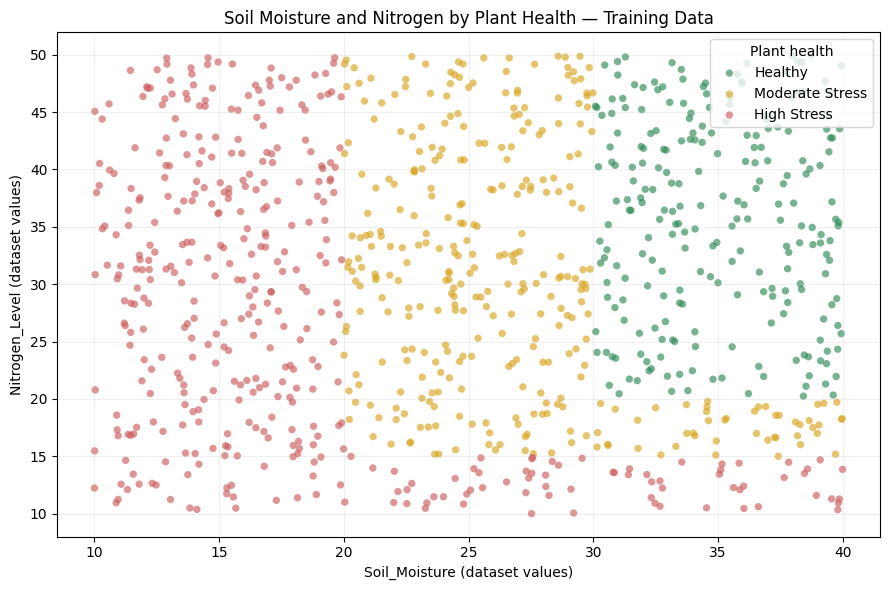

Soil_Moisture               Nitrogen_Level              
                           median    min    max         median    min    max
Plant_Health_Status                                                         
Healthy                     34.41  30.09  39.95          35.69  20.25  49.95
Moderate Stress             25.84  20.01  39.97          30.04  15.00  49.87
High Stress                 16.18  10.00  39.99          27.19  10.00  49.73

In [7]:
class_colours = {
    "Healthy": "seagreen",
    "Moderate Stress": "goldenrod",
    "High Stress": "indianred"
}

fig, ax = plt.subplots(figsize=(9, 6))

for health_class, colour in class_colours.items():
    subset = train_df[
        train_df["Plant_Health_Status"] == health_class
    ]

    ax.scatter(
        subset["Soil_Moisture"],
        subset["Nitrogen_Level"],
        label=health_class,
        color=colour,
        alpha=0.65,
        s=28,
        edgecolors="none"
    )

ax.set_title("Soil Moisture and Nitrogen by Plant Health — Training Data")
ax.set_xlabel("Soil_Moisture (dataset values)")
ax.set_ylabel("Nitrogen_Level (dataset values)")
ax.legend(title="Plant health")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

sensor_class_summary = (
    train_df.groupby("Plant_Health_Status")[
        ["Soil_Moisture", "Nitrogen_Level"]
    ]
    .agg(["median", "min", "max"])
    .reindex(class_names)
)

display(sensor_class_summary.round(2))

The training plot shows higher median soil moisture for Healthy observations (34.41) than Moderate Stress (25.84) or High Stress (16.18). High Stress also occurs at high moisture when nitrogen is low. The combined feature pattern is informative but does not establish causation or the original label-generation rule.

**Preprocessing Part 2: Timestamp Feature Engineering**

We extract the hour from each timestamp and represent it using sine and cosine features. This preserves the repeating 24 hour cycle, so times close to midnight remain close together. These features may help capture daily patterns; their usefulness will be assessed during feature selection and model evaluation.

In [8]:
def add_time_features(data):
    result = data.copy()

    timestamps = pd.to_datetime(
        result["Timestamp"],
        errors="raise"
    )

    hour = timestamps.dt.hour

    result["Hour_sin"] = np.sin(2 * np.pi * hour / 24)
    result["Hour_cos"] = np.cos(2 * np.pi * hour / 24)

    return result.drop(columns=["Timestamp"])


train_features_df = add_time_features(train_df)
test_features_df = add_time_features(test_df)

display(
    pd.DataFrame({
        "Original timestamp": train_df["Timestamp"],
        "Hour_sin": train_features_df["Hour_sin"],
        "Hour_cos": train_features_df["Hour_cos"]
    }).head()
)

,Original timestamp,Hour_sin,Hour_cos
0,2024-10-03 10:54:53.407995,0.500000,-0.866025
1,2024-10-03 16:54:53.407995,-0.866025,-0.500000
2,2024-10-03 22:54:53.407995,-0.500000,0.866025
3,2024-10-04 04:54:53.407995,0.866025,0.500000
4,2024-10-04 10:54:53.407995,0.500000,-0.866025


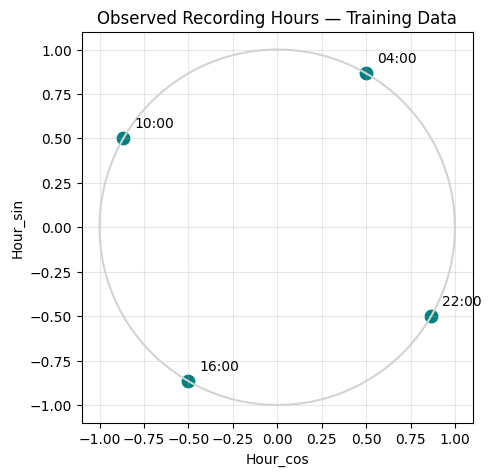

In [9]:
observed_hours = sorted(
    pd.to_datetime(train_df["Timestamp"]).dt.hour.unique()
)

angles = 2 * np.pi * np.array(observed_hours) / 24
circle = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(
    np.cos(circle),
    np.sin(circle),
    color="lightgray"
)

ax.scatter(
    np.cos(angles),
    np.sin(angles),
    color="teal",
    s=80
)

for hour, angle in zip(observed_hours, angles):
    ax.annotate(
        f"{hour:02d}:00",
        (np.cos(angle), np.sin(angle)),
        xytext=(8, 8),
        textcoords="offset points"
    )

ax.set_xlabel("Hour_cos")
ax.set_ylabel("Hour_sin")
ax.set_title("Observed Recording Hours — Training Data")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
excluded_columns = ["Plant_Health_Status", "Plant_ID"]

X_train = train_features_df.drop(columns=excluded_columns)
X_test = test_features_df.drop(columns=excluded_columns)

groups_train = train_df["Plant_ID"].copy()
groups_test = test_df["Plant_ID"].copy()

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_train.columns.equals(X_test.columns)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)
print("\nInput features:")
print(X_train.columns.tolist())

Training input shape: (960, 13)
Testing input shape: (240, 13)

Input features:
['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Hour_sin', 'Hour_cos']


**Preprocessing Part 3: Outlier Detection Using IQR**

We use the Interquartile Range (IQR) to identify unusually low or high sensor readings. IQR is the difference between the 75th percentile (Q3) and the 25th percentile (Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for investigation. We calculate these limits using training data only.

In [11]:
# Apply IQR detection to the original sensor measurements.
# The engineered time features are excluded.
sensor_columns = [
    column for column in X_train.columns
    if column not in ["Hour_sin", "Hour_cos"]
]

print("Number of sensor features:", len(sensor_columns))
print(sensor_columns)

Number of sensor features: 11
['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']


In [12]:
Q1 = X_train[sensor_columns].quantile(0.25)
Q3 = X_train[sensor_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

outlier_flags = (
    (X_train[sensor_columns] < lower_bounds)
    | (X_train[sensor_columns] > upper_bounds)
)

iqr_summary = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Lower bound": lower_bounds,
    "Upper bound": upper_bounds,
    "Outlier count": outlier_flags.sum()
})

display(iqr_summary.round(3))

rows_with_outliers = outlier_flags.any(axis=1)

print(
    "Training rows with at least one flagged value:",
    int(rows_with_outliers.sum())
)

,Q1,Q3,IQR,Lower bound,Upper bound,Outlier count
Soil_Moisture,17.336,32.328,14.992,-5.152,54.815,0
Ambient_Temperature,21.102,26.802,5.701,12.551,35.353,0
Soil_Temperature,17.299,22.535,5.236,9.444,30.390,0
Humidity,47.260,62.469,15.209,24.447,85.283,0
Light_Intensity,426.226,809.562,383.337,-148.779,1384.567,0
Soil_pH,6.022,7.020,0.998,4.525,8.516,0
Nitrogen_Level,20.510,40.396,19.886,-9.320,70.225,0
Phosphorus_Level,21.308,39.907,18.599,-6.590,67.805,0
Potassium_Level,20.167,40.463,20.296,-10.277,70.907,0
Chlorophyll_Content,27.395,42.142,14.746,5.276,64.261,0


Training rows with at least one flagged value: 0


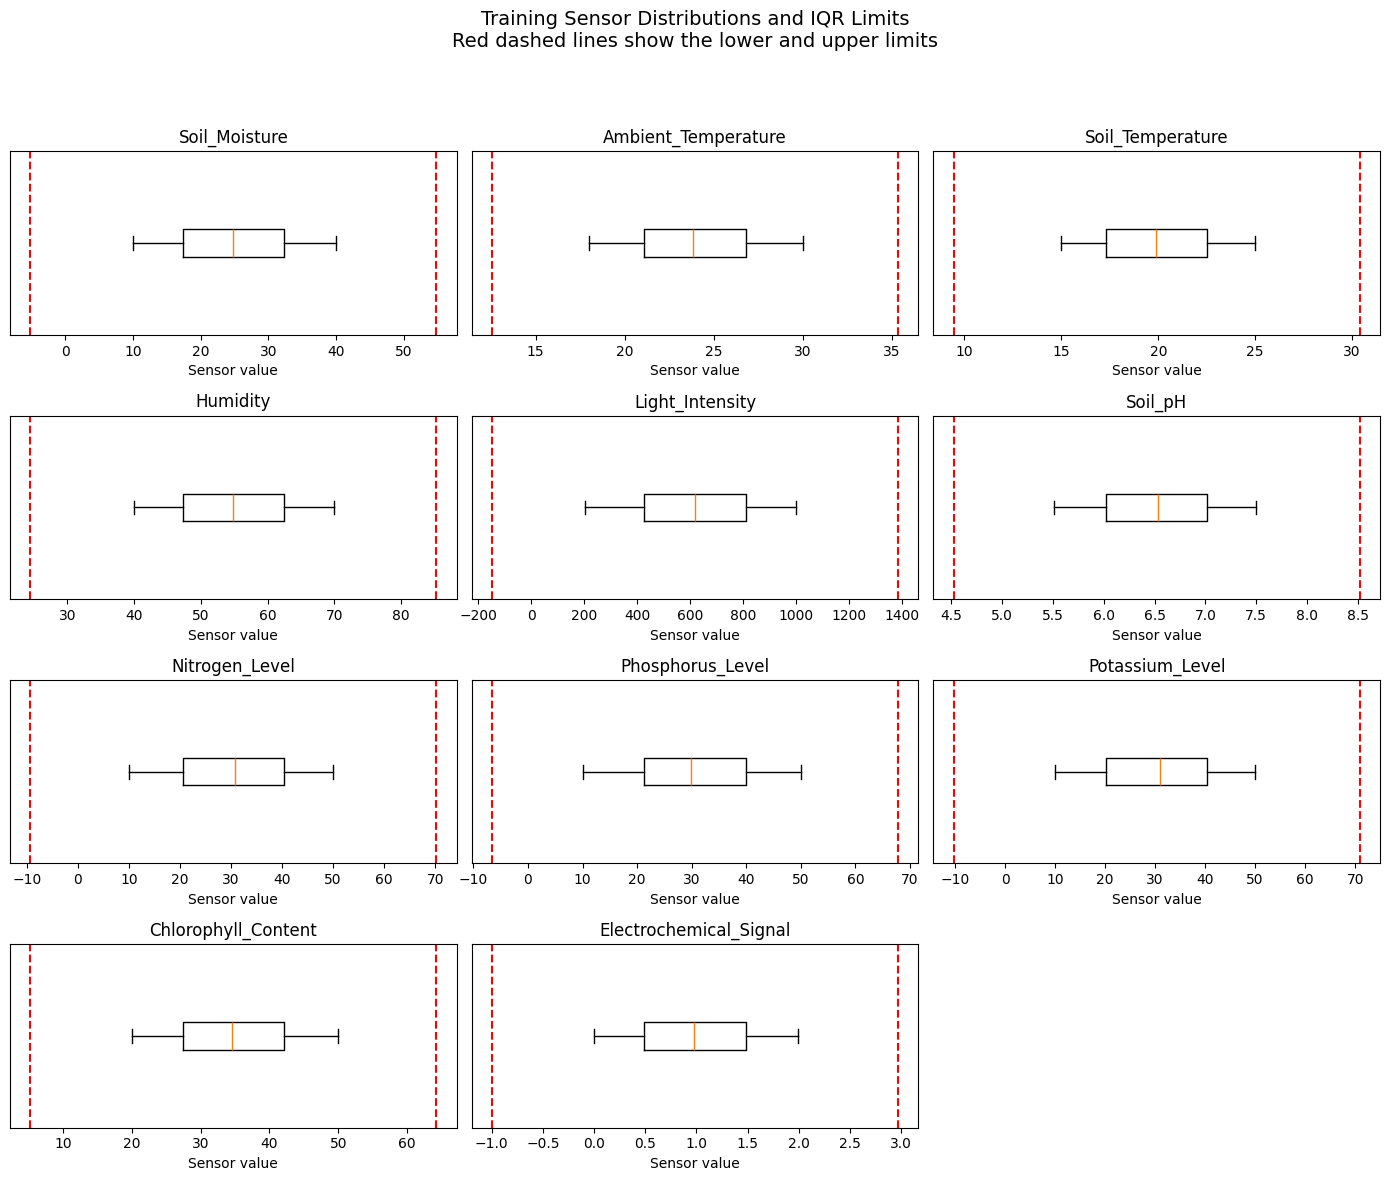

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.ravel()

for index, column in enumerate(sensor_columns):
    ax = axes[index]

    ax.boxplot(
        X_train[column].dropna(),
        vert=False,
        whis=1.5
    )

    ax.axvline(
        lower_bounds[column],
        color="red",
        linestyle="--"
    )

    ax.axvline(
        upper_bounds[column],
        color="red",
        linestyle="--"
    )

    ax.set_title(column)
    ax.set_xlabel("Sensor value")
    ax.set_yticks([])

# Hide unused panels.
for index in range(len(sensor_columns), len(axes)):
    axes[index].set_visible(False)

fig.suptitle(
    "Training Sensor Distributions and IQR Limits\n"
    "Red dashed lines show the lower and upper limits",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

IQR detection identified zero outliers in the 11 training sensor features. Therefore, all training observations were retained without clipping or removal. This means no values were flagged by the chosen statistical rule; it does not prove that every reading is physically correct. Outlier detection was completed even though no corrective changes were needed.

**Preprocessing Part 4: Feature Standardization**

Our input features have different numerical ranges. StandardScaler transforms each feature by subtracting its training mean and dividing by its training standard deviation. This gives nonconstant training features a mean approximately equal to zero and a standard deviation approximately equal to one. Scaling is useful for SVM and distance based methods such as SMOTE.

In [14]:
before_scaling = pd.DataFrame({
    "Minimum": X_train.min(),
    "Maximum": X_train.max(),
    "Mean": X_train.mean(),
    "Standard deviation": X_train.std(ddof=0)
})

display(before_scaling.round(3))

,Minimum,Maximum,Mean,Standard deviation
Soil_Moisture,10.001,39.993,25.062,8.622
Ambient_Temperature,18.004,29.991,23.933,3.399
Soil_Temperature,15.004,24.996,19.896,2.938
Humidity,40.029,69.969,54.948,8.732
Light_Intensity,201.507,999.660,615.681,224.193
Soil_pH,5.509,7.498,6.515,0.586
Nitrogen_Level,10.004,49.951,30.570,11.478
Phosphorus_Level,10.018,49.974,30.283,11.306
Potassium_Level,10.001,49.982,30.371,11.639
Chlorophyll_Content,20.026,49.991,34.750,8.745


In [15]:
from sklearn.preprocessing import StandardScaler

scaler_demo = StandardScaler()

# Learn the scaling parameters from training data.
X_train_scaled = pd.DataFrame(
    scaler_demo.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply those same parameters to the test data.
X_test_scaled = pd.DataFrame(
    scaler_demo.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Hour_sin,Hour_cos
0,0.285204,-0.498120,0.682160,0.039338,-0.265435,-1.592697,-1.791704,1.373097,0.747972,0.109001,-0.081303,0.707107,-1.224745
1,-1.186032,-0.655071,-0.413701,1.030826,-0.087178,1.060449,0.012461,-0.432401,-1.067646,-0.772656,-1.434833,-1.224745,-0.707107
2,-0.924991,-0.809767,-1.532847,1.476194,-0.109534,-1.464803,-0.107378,-0.239623,0.458448,1.017371,0.163301,-0.707107,1.224745
3,-1.127975,-0.394251,0.980998,0.371340,-1.669407,-1.588312,-1.185089,-0.362851,-0.353396,0.353163,0.345212,1.224745,0.707107
4,1.711854,1.469716,-0.611105,1.010538,-0.763573,-1.015959,-1.709697,0.673633,0.625817,1.545643,1.083798,0.707107,-1.224745


Training shape: (960, 13)
Testing shape: (240, 13)


In [16]:
scaling_check = pd.DataFrame({
    "Training mean after scaling": X_train_scaled.mean(),
    "Training SD after scaling": X_train_scaled.std(ddof=0)
})

display(scaling_check.round(6))

assert np.allclose(
    X_train_scaled.mean().to_numpy(),
    0,
    atol=1e-10
)

# A constant feature would have SD 0 after scaling.
nonconstant_features = X_train.columns[scaler_demo.var_ > 0]

assert np.allclose(
    X_train_scaled[nonconstant_features].std(ddof=0).to_numpy(),
    1,
    atol=1e-10
)

print("Standardization checks passed.")

,Training mean after scaling,Training SD after scaling
Soil_Moisture,0.0,1.0
Ambient_Temperature,0.0,1.0
Soil_Temperature,0.0,1.0
Humidity,0.0,1.0
Light_Intensity,0.0,1.0
Soil_pH,-0.0,1.0
Nitrogen_Level,-0.0,1.0
Phosphorus_Level,0.0,1.0
Potassium_Level,0.0,1.0
Chlorophyll_Content,-0.0,1.0


Standardization checks passed.


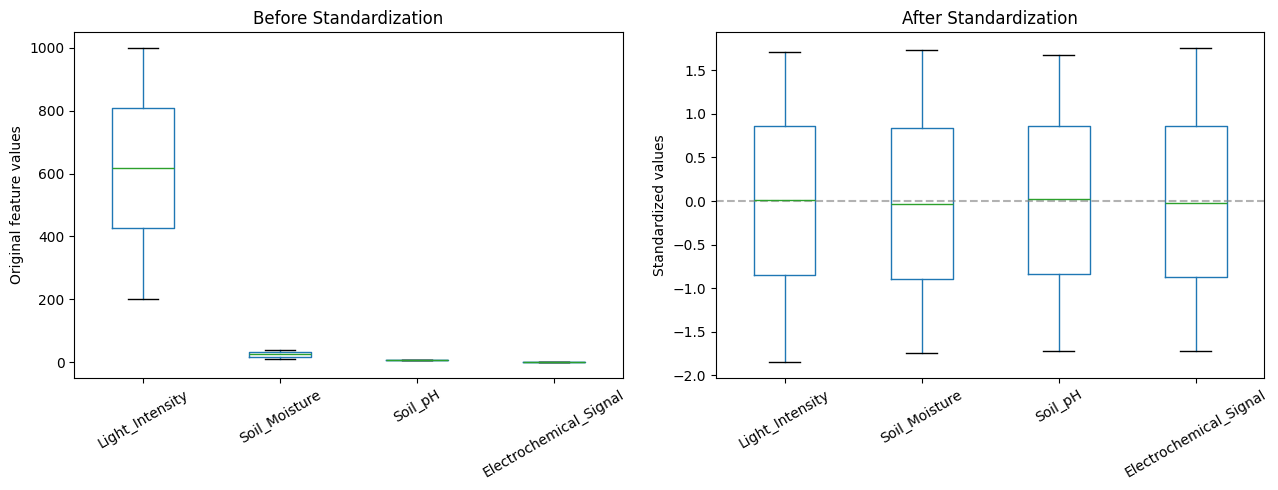

In [17]:
plot_features = [
    "Light_Intensity",
    "Soil_Moisture",
    "Soil_pH",
    "Electrochemical_Signal"
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

X_train[plot_features].boxplot(
    ax=axes[0],
    rot=30,
    grid=False
)

axes[0].set_title("Before Standardization")
axes[0].set_ylabel("Original feature values")

X_train_scaled[plot_features].boxplot(
    ax=axes[1],
    rot=30,
    grid=False
)

axes[1].set_title("After Standardization")
axes[1].set_ylabel("Standardized values")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

StandardScaler was fitted on training inputs and applied to both training and test inputs. The checks confirmed training means approximately zero and standard deviations approximately one for nonconstant features. The before-and-after plot shows that the features now have comparable scales. Standardization changes their scale without changing the number of observations or their labels.

**Preprocessing Part 5: Feature Selection Using Mutual Information**

Mutual information measures how much knowing a feature helps reduce uncertainty about the plant-health class. It can detect nonlinear relationships. We calculate feature scores using training data and select the highest-scoring features. The number of selected features will later be tuned through cross-validation.

In [18]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

feature_names = X_train_scaled.columns.tolist()

time_feature_mask = np.array([
    name in ["Hour_sin", "Hour_cos"]
    for name in feature_names
])


def calculate_mi(X, y):
    values = np.asarray(X, dtype=float).copy()

    # Represent each distinct time-feature value with an integer code.
    for column_index in np.flatnonzero(time_feature_mask):
        _, codes = np.unique(
            values[:, column_index],
            return_inverse=True
        )
        values[:, column_index] = codes

    return mutual_info_classif(
        values,
        y,
        discrete_features=time_feature_mask,
        random_state=RANDOM_STATE
    )

In [19]:
selector_demo = SelectKBest(
    score_func=calculate_mi,
    k=5
)

selector_demo.fit(X_train_scaled, y_train)

selected_mask = selector_demo.get_support()

mi_results = pd.DataFrame({
    "Feature": feature_names,
    "MI score": selector_demo.scores_,
    "Selected for demonstration": selected_mask
}).sort_values("MI score", ascending=False)

display(mi_results.round(4))

,Feature,MI score,Selected for demonstration
0,Soil_Moisture,0.7332,True
6,Nitrogen_Level,0.1659,True
5,Soil_pH,0.0126,True
7,Phosphorus_Level,0.0078,True
4,Light_Intensity,0.0076,True
2,Soil_Temperature,0.0073,False
1,Ambient_Temperature,0.0057,False
11,Hour_sin,0.0004,False
12,Hour_cos,0.0004,False
3,Humidity,0.0000,False


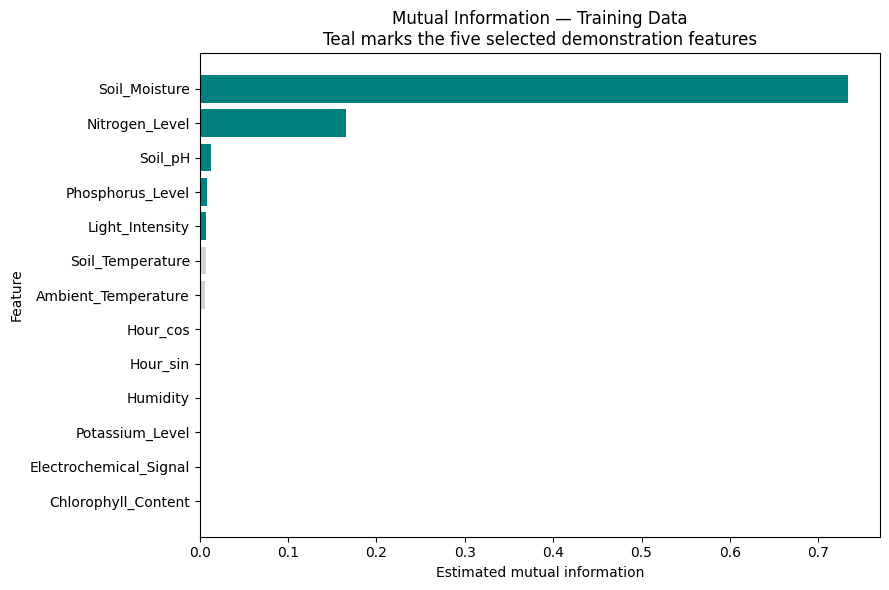

In [20]:
plot_data = mi_results.sort_values("MI score")

colors = [
    "teal" if selected else "lightgray"
    for selected in plot_data["Selected for demonstration"]
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_data["Feature"],
    plot_data["MI score"],
    color=colors
)

ax.set_title(
    "Mutual Information — Training Data\n"
    "Teal marks the five selected demonstration features"
)

ax.set_xlabel("Estimated mutual information")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
selected_features = X_train_scaled.columns[
    selected_mask
].tolist()

X_train_selected = pd.DataFrame(
    selector_demo.transform(X_train_scaled),
    columns=selected_features,
    index=X_train_scaled.index
)

X_test_selected = pd.DataFrame(
    selector_demo.transform(X_test_scaled),
    columns=selected_features,
    index=X_test_scaled.index
)

print("Selected features:", selected_features)
print("Training shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

display(X_train_selected.head())

Selected features: ['Soil_Moisture', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level']
Training shape: (960, 5)
Testing shape: (240, 5)


,Soil_Moisture,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level
0,0.285204,-0.265435,-1.592697,-1.791704,1.373097
1,-1.186032,-0.087178,1.060449,0.012461,-0.432401
2,-0.924991,-0.109534,-1.464803,-0.107378,-0.239623
3,-1.127975,-1.669407,-1.588312,-1.185089,-0.362851
4,1.711854,-0.763573,-1.015959,-1.709697,0.673633


Mutual information was calculated using training inputs and labels. Five features were selected for demonstration, and the same columns were retained in the test set. During model tuning, feature selection will be repeated within each training fold, and different feature counts—including all features—will be compared. A score near zero means little individual dependence was detected; it does not prove that a feature is useless when combined with others.

**Preprocessing Part 6: Class-Imbalance Handling**

Our training data contains 235 Healthy, 335 Moderate Stress, and 390 High Stress observations. We use SMOTE—Synthetic Minority Over-sampling Technique—to generate additional training examples for the smaller classes. SMOTE creates synthetic examples between neighbouring observations of the same class. We apply it only to training data and evaluate its usefulness during model comparison.

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
smote_demo = SMOTE(
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = smote_demo.fit_resample(
    X_train_selected,
    y_train
)

print("Training shape before SMOTE:", X_train_selected.shape)
print("Training shape after SMOTE:", X_train_balanced.shape)

print(
    "Synthetic observations added:",
    len(y_train_balanced) - len(y_train)
)

print("Test shape remains:", X_test_selected.shape)

Training shape before SMOTE: (960, 5)
Training shape after SMOTE: (1170, 5)
Synthetic observations added: 210
Test shape remains: (240, 5)


In [24]:
class_order = [0, 1, 2]
label_names = ["Healthy", "Moderate Stress", "High Stress"]

before_counts = (
    y_train.value_counts()
    .reindex(class_order, fill_value=0)
)

after_counts = (
    pd.Series(y_train_balanced).value_counts()
    .reindex(class_order, fill_value=0)
)

balance_summary = pd.DataFrame({
    "Before SMOTE": before_counts.to_numpy(),
    "After SMOTE": after_counts.to_numpy()
}, index=label_names)

balance_summary["Synthetic examples added"] = (
    balance_summary["After SMOTE"]
    - balance_summary["Before SMOTE"]
)

display(balance_summary)

assert after_counts.nunique() == 1

print("Class-balancing check passed.")

,Before SMOTE,After SMOTE,Synthetic examples added
Healthy,235,390,155
Moderate Stress,335,390,55
High Stress,390,390,0


Class-balancing check passed.


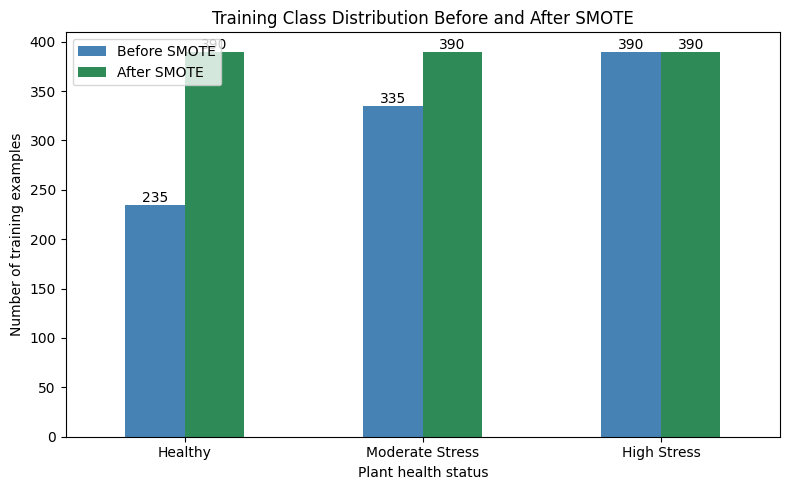

In [25]:
ax = balance_summary[
    ["Before SMOTE", "After SMOTE"]
].plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "seagreen"]
)

ax.set_title("Training Class Distribution Before and After SMOTE")
ax.set_xlabel("Plant health status")
ax.set_ylabel("Number of training examples")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

SMOTE increased the training dataset from 960 to 1,170 examples by adding 210 synthetic examples. Each health class now contains 390 examples. The test dataset retains its original 240 observations and class distribution. We will compare models with and without balancing using cross-validation to determine whether SMOTE improves performance.

## Grouped cross-validation
We tune SVM on four grouped validation folds. Observations from the same plant stay together. Scaling, feature selection and resampling are fitted within each training fold. Macro-F1 weights the three classes equally; accuracy is also reported.

In [26]:
print("Original training inputs:", X_train.shape)
print("Training labels:", y_train.shape)
print("Number of training plants:", groups_train.nunique())

assert X_train.index.equals(y_train.index)
assert X_train.index.equals(groups_train.index)

assert set(groups_train).isdisjoint(set(groups_test))

assert "Plant_ID" not in X_train.columns
assert "Plant_Health_Status" not in X_train.columns

print("Training-data checks passed.")

Original training inputs: (960, 13)
Training labels: (960,)
Number of training plants: 8
Training-data checks passed.


In [27]:
# Reuse the exact four StratifiedGroupKFold partitions recorded in the master.
# Explicit plant IDs avoid differences in fold generation across sklearn versions.
validation_plant_groups = [[4, 8], [1, 3], [6, 10], [5, 7]]
cv_splits = []
for validation_plants in validation_plant_groups:
    is_validation = groups_train.isin(validation_plants).to_numpy()
    cv_splits.append((np.flatnonzero(~is_validation), np.flatnonzero(is_validation)))
assert sorted(np.concatenate([val for _, val in cv_splits]).tolist()) == list(range(len(X_train)))
print("Number of cross-validation folds:", len(cv_splits))


Number of cross-validation folds: 4


In [28]:
fold_details = []

for fold_number, (fit_idx, val_idx) in enumerate(
    cv_splits,
    start=1
):
    fit_plants = set(groups_train.iloc[fit_idx])
    val_plants = set(groups_train.iloc[val_idx])

    fit_labels = y_train.iloc[fit_idx]
    val_labels = y_train.iloc[val_idx]

    # No plant may appear on both sides of a fold.
    assert fit_plants.isdisjoint(val_plants)

    # Confirm all three health classes are represented.
    assert set(fit_labels) == {0, 1, 2}
    assert set(val_labels) == {0, 1, 2}

    fold_details.append({
        "Fold": fold_number,
        "Training rows": len(fit_idx),
        "Validation rows": len(val_idx),
        "Training plants": sorted(fit_plants),
        "Validation plants": sorted(val_plants),
        "Validation Healthy": int((val_labels == 0).sum()),
        "Validation Moderate Stress": int((val_labels == 1).sum()),
        "Validation High Stress": int((val_labels == 2).sum())
    })

fold_summary = pd.DataFrame(fold_details)

display(fold_summary)

print("All folds passed the group and class checks.")

,Fold,Training rows,Validation rows,Training plants,Validation plants,Validation Healthy,Validation Moderate Stress,Validation High Stress
0,1,720,240,"[1, 3, 5, 6, 7, 10]","[4, 8]",56,86,98
1,2,720,240,"[4, 5, 6, 7, 8, 10]","[1, 3]",63,86,91
2,3,720,240,"[1, 3, 4, 5, 7, 8]","[6, 10]",57,87,96
3,4,720,240,"[1, 3, 4, 6, 8, 10]","[5, 7]",59,76,105


All folds passed the group and class checks.


## Individual model: SVM
An RBF SVM learns nonlinear decision boundaries. C controls the penalty for classification errors; gamma controls the locality of the kernel. Standardization matters because the RBF kernel uses distances. Large C or gamma can produce overly complex boundaries.

We compare 2, 3, 5 and all 13 features, with and without resampling. IQR is detection only: zero flagged training observations were retained. Fixed target mapping and timestamp transformations do not learn from labels. SMOTENC preserves observed time-feature combinations when time columns are selected.

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, ParameterGrid
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn import FunctionSampler
from imblearn.over_sampling import SMOTE, SMOTENC


In [30]:
class IQRDetector(BaseEstimator, TransformerMixin):
    def __init__(self, columns, multiplier=1.5):
        self.columns = columns
        self.multiplier = multiplier

    def fit(self, X, y=None):
        sensor_data = X.loc[:, self.columns]

        q1 = sensor_data.quantile(0.25)
        q3 = sensor_data.quantile(0.75)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.multiplier * iqr
        self.upper_bounds_ = q3 + self.multiplier * iqr

        flags = (
            (sensor_data < self.lower_bounds_)
            | (sensor_data > self.upper_bounds_)
        )

        self.outlier_counts_ = flags.sum()
        self.flagged_rows_ = int(flags.any(axis=1).sum())

        return self

    def transform(self, X):
        # Detection only: retain the measurements.
        return X.copy()

In [31]:
def resample_training(X, y):
    time_columns = [
        column for column in X.columns
        if column in ["Hour_sin", "Hour_cos"]
    ]

    # Use ordinary SMOTE when only sensor features are selected.
    if not time_columns:
        return SMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=5
        ).fit_resample(X, y)

    continuous_columns = [
        column for column in X.columns
        if column not in time_columns
    ]

    # Store each observed time-feature combination as one category.
    time_combinations, time_codes = np.unique(
        X[time_columns].to_numpy(),
        axis=0,
        return_inverse=True
    )

    combined = np.column_stack([
        X[continuous_columns].to_numpy(),
        time_codes
    ])

    sampler = SMOTENC(
        categorical_features=[len(continuous_columns)],
        random_state=RANDOM_STATE,
        k_neighbors=5
    )

    resampled_values, resampled_y = sampler.fit_resample(
        combined, y
    )

    result = pd.DataFrame(
        resampled_values[:, :-1],
        columns=continuous_columns
    )

    restored_time = time_combinations[
        resampled_values[:, -1].astype(int)
    ]

    for index, column in enumerate(time_columns):
        result[column] = restored_time[:, index]

    return result[X.columns], resampled_y

In [32]:
def build_tuning_pipeline(model):
    return ImbPipeline([
        (
            "iqr",
            IQRDetector(columns=sensor_columns)
        ),
        (
            "scaler",
            StandardScaler().set_output(transform="pandas")
        ),
        (
            "selection",
            SelectKBest(
                score_func=calculate_mi,
                k=5
            ).set_output(transform="pandas")
        ),
        (
            "balancing",
            "passthrough"
        ),
        (
            "model",
            model
        )
    ])


balancing_options = [
    "passthrough",
    FunctionSampler(
        func=resample_training,
        validate=False
    )
]

In [33]:
scoring = {
    "accuracy": "accuracy",
    "macro_f1": make_scorer(f1_score, average="macro", labels=[0, 1, 2], zero_division=0)
}
model_name = 'SVM'
model = SVC(kernel="rbf")
model_parameters = {'model__C': [0.1, 1, 10, 100], 'model__gamma': ['scale', 0.01, 0.1]}
parameters = {
    "selection__k": [2, 3, 5, "all"],
    "balancing": balancing_options,
    **model_parameters
}
print("Configurations:", len(ParameterGrid(parameters)))
print("CV fits:", len(ParameterGrid(parameters)) * len(cv_splits))
print("One additional final refit is performed after selection.")
search = GridSearchCV(
    build_tuning_pipeline(model), parameters,
    scoring=scoring, refit="macro_f1", cv=cv_splits,
    n_jobs=2, error_score="raise", verbose=1
)
search.fit(X_train, y_train)
print("Search completed.")


Configurations: 96
CV fits: 384
One additional final refit is performed after selection.
Fitting 4 folds for each of 96 candidates, totalling 384 fits
Search completed.


In [34]:
raw_results = pd.DataFrame(search.cv_results_)
parameter_columns = [c for c in raw_results if c.startswith("param_") and c != "param_balancing"]
configuration_results = raw_results[parameter_columns + [
    "mean_test_accuracy", "mean_test_macro_f1", "std_test_macro_f1", "rank_test_macro_f1"
]].copy()
configuration_results["Resampling"] = raw_results["param_balancing"].apply(
    lambda value: "No" if isinstance(value, str) else "Yes"
)
configuration_results = configuration_results.sort_values("mean_test_macro_f1", ascending=False, kind="stable")
# Show all configurations and preserve small smoothing parameters in scientific notation.
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(configuration_results)
print("Best CV Macro-F1:", search.best_score_)
for key, value in search.best_params_.items():
    if key != "balancing": print(key, ":", value)
final_model = search.best_estimator_
selected_features = X_train.columns[final_model.named_steps["selection"].get_support()].tolist()
print("Selected features:", selected_features)
print("Resampling:", "No" if isinstance(final_model.named_steps["balancing"], str) else "Yes")
balancing_summary = configuration_results.groupby("Resampling")["mean_test_macro_f1"].max()
display(balancing_summary.rename("Best CV Macro-F1"))


,param_model__C,param_model__gamma,param_selection__k,mean_test_accuracy,mean_test_macro_f1,std_test_macro_f1,rank_test_macro_f1,Resampling
36,100.0,scale,2,0.984375,0.985564,0.007641,1,No
84,100.0,scale,2,0.983333,0.984302,0.006998,2,Yes
24,10.0,scale,2,0.972917,0.974222,0.011102,3,No
92,100.0,0.1,2,0.973958,0.974180,0.004627,4,Yes
72,10.0,scale,2,0.971875,0.972854,0.005356,5,Yes
44,100.0,0.1,2,0.970833,0.971756,0.005549,6,No
45,100.0,0.1,3,0.966667,0.966026,0.012249,7,No
93,100.0,0.1,3,0.964583,0.963433,0.014282,8,Yes
85,100.0,scale,3,0.960417,0.958749,0.008766,9,Yes
12,1.0,scale,2,0.958333,0.957664,0.006525,10,No


Best CV Macro-F1: 0.9855642189685064
model__C : 100
model__gamma : scale
selection__k : 2
Selected features: ['Soil_Moisture', 'Nitrogen_Level']
Resampling: No


,Best CV Macro-F1
Resampling,
No,0.985564
Yes,0.984302


## Test evaluation
The configuration is now fixed by training set CV. Apply the fitted pipeline to the original 13 feature test inputs. Test observations are not resampled. Report the results without tuning further against them.

,Model,Best CV Macro-F1,CV Macro-F1 SD,Test accuracy,Test Macro-F1,Incorrect predictions
0,SVM,0.985564,0.007641,0.983333,0.980674,4


                 precision    recall  f1-score   support

        Healthy     1.0000    0.9531    0.9760        64
Moderate Stress     0.9429    1.0000    0.9706        66
    High Stress     1.0000    0.9909    0.9954       110

       accuracy                         0.9833       240
      macro avg     0.9810    0.9813    0.9807       240
   weighted avg     0.9843    0.9833    0.9834       240



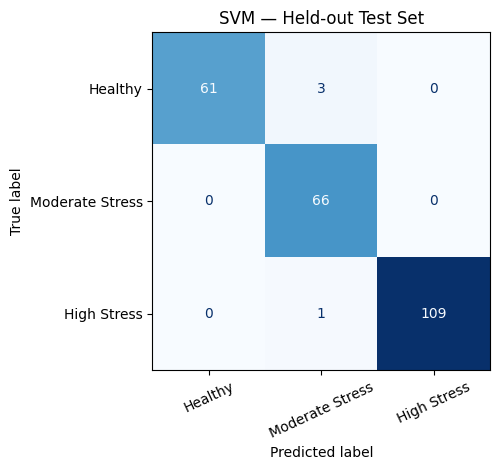

In [35]:
predictions = final_model.predict(X_test)
summary = pd.DataFrame([{
    "Model": model_name,
    "Best CV Macro-F1": search.best_score_,
    "CV Macro-F1 SD": search.cv_results_["std_test_macro_f1"][search.best_index_],
    "Test accuracy": accuracy_score(y_test, predictions),
    "Test Macro-F1": f1_score(y_test, predictions, average="macro", labels=[0,1,2], zero_division=0),
    "Incorrect predictions": int(np.sum(predictions != y_test.to_numpy()))
}])
display(summary)
print(classification_report(y_test, predictions, labels=[0,1,2], target_names=class_names, digits=4, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, labels=[0,1,2], display_labels=class_names, cmap="Blues", colorbar=False, xticks_rotation=25)
plt.title(model_name + " — Held-out Test Set")
plt.tight_layout()
plt.show()


## Recorded result and conclusion

The independently executed notebook reproduces the group master results (rounded): best CV Macro-F1 **0.985564**, test accuracy **98.33%**, test Macro-F1 **0.980674**, and **4 errors out of 240**.

Selected settings: RBF kernel, C=100, gamma=scale, two features, no resampling. Best CV Macro-F1 was 0.985564 without resampling versus 0.984302 with. Standardization is part of the fitted pipeline.

Unless stated otherwise, the two selected features are Soil_Moisture and Nitrogen_Level. These scores apply to the tested split and parameter grid, not all possible settings or real-world plants. Compare the full configuration and class-wise tables above during the viva.